<a href="https://colab.research.google.com/github/nicc0614/2025.02.18/blob/main/%E6%8A%95%E8%B3%87%E5%B0%8F%E5%8A%A9%E6%89%8B-python%20x%20%E8%B2%A1%E5%A0%B1%E5%88%86%E6%9E%90%20.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# 專案報告: 投資小助手

## 專案背景與動機

### 專案背景  
自2022年 ChatGPT 問世以來，帶來了新一波科技革命，其中台灣更是受惠於這股 AI 浪潮，投資人紛紛看好未來發展，推動科技股價水漲船高，進一步帶動台灣股市的熱絡，吸引越來越多人投入市場。而在評估一家企業的投資價值時，最重要的就是能夠深入分析其財務狀況。因此，本專案將透過 Python 串接 LINE Bot 及 Gemini 生成式語言模型，並於 Colab 平台建構一套財務報表查詢與分析系統，期望藉此為缺乏專業背景知識的投資人提供實用的參考意見。

### 專案目標  

*   建立一個能夠從 Goodinfo 抓取財報並能透過 Google Gemini 有效分析財務報表的 LINE Bot。
*   選擇一個大眾較為熟悉的社群媒體平台，打造簡單明瞭的互動畫面，降低使用者操作生成式 AI 的門檻。



## 系統設計與架構



### 系統功能分析  

| 功能項目 | 說明 |
|----------|------|
| 使用者訊息接收 | 使用者透過 LINE 傳送訊息，Bot 接收並執行 |
| 選單選擇 | 使用者點選 LINE Bot 提供的選項，執行欲使用的服務 |
| 財報找尋 | 使用者點選財報找尋選單並輸入公司代號後，即可獲取該公司的三大報表網址 |
| 財報分析 | 使用者點選財報分析選單並輸入公司代號後，可選取欲分析的項目，即可獲取 Google Gemini 的回覆 |
| Gemini API 連接 | 將使用者選擇的分析項目所對應的prompt傳送至 Google Gemini 並取得 AI 回覆 |
| 回應傳送 | Bot 將 Gemini 的回應以文字方式回傳給使用者 |
| 錯誤處理 | 在使用者輸入錯誤訊息後回到主選單 |

### 系統架構圖
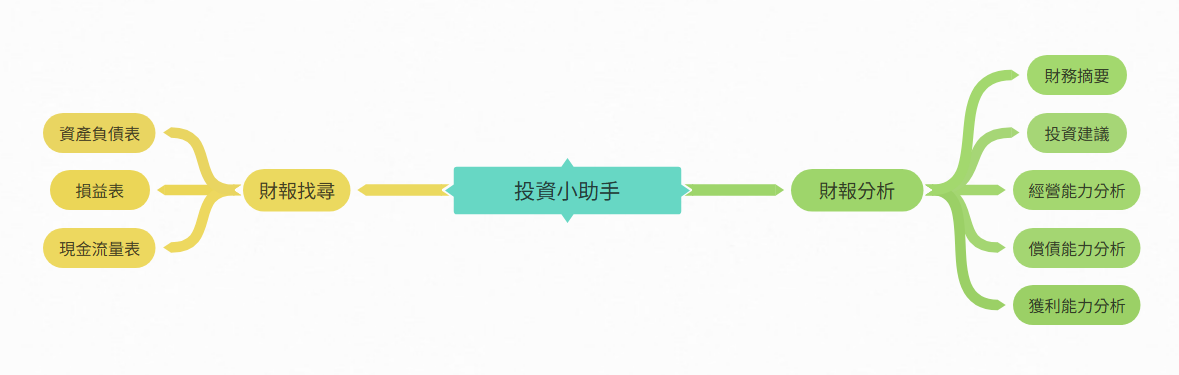

### 使用的技術  

| 技術項目 | 說明 |
|----------|------|
| 程式語言 | Python (colab) |
| 框架 | Flask（建立 webhook） |
|互動介面平台 | line |
| API 使用 | Google Gemini API（文字生成），LINE Messaging API（對話） |
| 資料格式 | JSON 處理傳輸與接收資料 |

### 使用的套件

|套件|說明|
|----------|------|
|flask-ngrok|flask 結合 ngrok 可以架設一個簡單公開的 HTTPS 伺服器，讓其他人（LINE Bot）可以透過網路存取網站或 API|
|line-bot-sdk==3.4.0|由 LINE 官方建立，用來與 LINE Messaging API 溝通，處理訊息收發、按鈕選單等|
|beautifulsoup4|解析 HTML/XML 的工具，以從網頁中擷取資料|
|google-generativeai|由 Google 官方建立，用來與 Gemini 生成式語言模型互動|
|pyngrok|讓開發者能夠從 Python 程式內管理與控制 ngrok 的啟動與連線，並獲得 HTTPS 網址|

### 使用的網站
[Goodinfo!台灣股市資訊網](https://goodinfo.tw/tw/index.asp)

## 專案成果與效益

### 系統程式

In [ ]:
!pip install --upgrade pip setuptools wheel

In [ ]:
%pip install -U "line-bot-sdk>=3.19.0" "aiohttp>=3.10.9,<4" --only-binary=:all:

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 10.1 MB/s  0:00:00
  Attempting uninstall: aiohttp
    Found existing installation: aiohttp 3.9.5
    Uninstalling aiohttp-3.9.5:
      Successfully uninstalled aiohttp-3.9.5


In [ ]:
!pip install flask-ngrok beautifulsoup4 google-generativeai pyngrok

  Using cached flask_ngrok-0.0.25-py3-none-any.whl.metadata (1.8 kB)
  Using cached pyngrok-7.3.0-py3-none-any.whl.metadata (8.1 kB)
Using cached flask_ngrok-0.0.25-py3-none-any.whl (3.1 kB)
Using cached pyngrok-7.3.0-py3-none-any.whl (25 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [flask-ngrok]


In [ ]:
from flask import Flask, request, abort
from flask_ngrok import run_with_ngrok
from google.colab import userdata
from linebot.v3 import WebhookHandler
from linebot.v3.exceptions import InvalidSignatureError
from linebot.v3.webhooks import MessageEvent, TextMessageContent
from linebot.v3.messaging import (
    Configuration, ApiClient, MessagingApi,
    ReplyMessageRequest, TextMessage,
    TemplateMessage, ButtonsTemplate, CarouselTemplate, CarouselColumn,
    MessageAction, URIAction
)
import requests, re, time, pandas as pd
from bs4 import BeautifulSoup
import google.generativeai as genai
from pyngrok import ngrok

app = Flask(__name__)

def ngrok_start():
    ngrok.set_auth_token(userdata.get('ngrok_authtoken'))
    ngrok.connect(5000)
    run_with_ngrok(app)

configuration = Configuration(access_token=userdata.get('Line_channel_token'))
handler = WebhookHandler(userdata.get('line_channel_secret'))
genai.configure(api_key=userdata.get("google_API_KEY"))
model = genai.GenerativeModel("gemini-2.0-flash-exp")

user_states = {}

def call_gemini_with_throttle(prompt, files=None):
    if files is None:
        files = []
    time.sleep(0.6)
    return model.generate_content([prompt] + files)

def crawl_financial_data(stock_id):

    headers = {
        'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/136.0.0.0 Safari/537.36',
        'Cookie': 'CLIENT%5FID=20250424145048398%5F72%2E14%2E201%2E169; _ga=GA1.1.1250369642.1745477458; _cc_id=cef04214d728af12439013890d2f3086; IS_TOUCH_DEVICE=F; SCREEN_SIZE=WIDTH=1536&HEIGHT=864; TW_STOCK_BROWSE_LIST=2330%7C4162%7C6625; panoramaId_expiry=1748594103124; panoramaId=de27ed2b905a000c7436a45c40d54945a702fa1de5b0702b607c20e3087bed50; panoramaIdType=panoIndiv; cto_bundle=35GF7F84ZWtaTTBGNU1BNlZNR25jMHhRbWZSV2hMQlNuRkhDekxCbFh3cGZodEJYRE5TSDJ1aERja200VGVBMEZkSWprWHV1Y0lHU1ZnQVE0bktwWUNSMjNHU0dReVZXbTN2SWRRJTJGbDZYMFQ5RTNGTlFUMjlEN1pXT2dVZlYwUlkxOTRuWCUyRjhkWktqRTNNSzFMalFmRDVlZXVDJTJGWlZrVnJkNzhJQ0t2SnM3TlM2UTE5WW45aExhMXcwWHhNUVJyd1ZVU3JzTWlCMzNWcE1QZFp6SHVueDRHRmVBVTZ2TWJiTGZwaW1Td2NZYXdZdnVjVWxHTTJVOGklMkZRVERrRWREaktWUkNFSlI; FCNEC=%5B%5B%22AKsRol-apmRrzB2uInpu5UDmPF03GCxYycrkySAALLCuRnT--AIdPMNv1guFECNkVyWqnbNZ2FucYm9tv9yHcwl_LeXaYZ7e-vr6hdfb0U0QElTtlLU4_bf2SiEnfJKpaeu3CH7p8xjf4x1KD5WQS5hk_jrScDtjWg%3D%3D%22%5D%5D; _ga_0LP5MLQS7E=GS2.1.s1748020303$o18$g1$t1748020616$j55$l0$h0$dxhQGwmCJk4PMX15OnXaza1sA8mYEOrWDCw'
    }

    def fetch_balance_sheet_with_cookie(stock_id: str):
        url = f'https://goodinfo.tw/tw/StockFinDetail.asp?RPT_CAT=BS_M_QUAR&STOCK_ID={stock_id}'
        res = requests.get(url, headers=headers)
        res.encoding = 'utf-8'

        soup = BeautifulSoup(res.text, 'lxml')
        table = soup.find("table", id="tblFinDetail")
        if not table:
            print("⚠️ 找不到表格")
            return None

        rows = table.find_all("tr")
        data = []
        for row in rows:
            cols = row.find_all(['th', 'td'])
            row_data = [col.get_text(strip=True).replace('\xa0', '') for col in cols]
            data.append(row_data)

        df = pd.DataFrame(data)

        if len(df) > 2:
            quarter_row = df.iloc[0].fillna('').tolist()
            type_row = df.iloc[1].fillna('').tolist()
            new_columns = ['項目']
            for i in range(1, len(quarter_row)):
                q_clean = quarter_row[i].replace(' ', '').replace('\xa0', '').strip()
                if q_clean:
                    new_columns.append(f'{q_clean}_金額')
                    new_columns.append(f'{q_clean}_%')
            new_columns = new_columns[:len(df.columns)]
            df.columns = new_columns
            df = df[2:]


            df = df[~df['項目'].isin(['負債', '股東權益', '金額'])]
        else:
            print("⚠️ 表格行數不足無法處理欄位名稱")
            return None

        path = f"/content/{stock_id}_資產負債表.csv"
        df.to_csv(path, index=False, encoding="utf-8-sig")
        return path

    def fetch_income_statement(stock_id: str):
        url = f'https://goodinfo.tw/tw/StockFinDetail.asp?RPT_CAT=IS_M_QUAR_ACC&STOCK_ID={stock_id}'
        res = requests.get(url, headers=headers)
        res.encoding = 'utf-8'

        soup = BeautifulSoup(res.text, 'lxml')
        table = soup.find("table", id="tblFinDetail")
        if not table:
            print("⚠️ 找不到表格")
            return None

        rows = table.find_all("tr")
        data = []
        for row in rows:
            cols = row.find_all(['th', 'td'])
            row_data = [col.get_text(strip=True).replace('\xa0', '') for col in cols]
            data.append(row_data)

        df = pd.DataFrame(data)

        if len(df) > 2:
            quarter_row = df.iloc[0].fillna('').tolist()
            type_row = df.iloc[1].fillna('').tolist()
            new_columns = ['項目']
            for i in range(1, len(quarter_row)):
                q_clean = quarter_row[i].replace(' ', '').replace('\xa0', '').strip()
                if q_clean:
                    new_columns.append(f'{q_clean}_金額')
                    new_columns.append(f'{q_clean}_%')
            new_columns = new_columns[:len(df.columns)]
            df.columns = new_columns
            df = df[2:]

            df = df[~df['項目'].isin(['業外損益', '淨損益', '金額'])]
        else:
            print("⚠️ 表格行數不足無法處理欄位名稱")
            return None
        path = f"/content/{stock_id}_損益表.csv"
        df.to_csv(path, index=False, encoding="utf-8-sig")
        return path

    def fetch_cashflow_sheet(stock_id: str):
        url = f'https://goodinfo.tw/tw/StockFinDetail.asp?RPT_CAT=CF_M_QUAR&STOCK_ID={stock_id}'
        res = requests.get(url, headers=headers)
        res.encoding = 'utf-8'

        soup = BeautifulSoup(res.text, 'lxml')
        table = soup.find("table", id="tblFinDetail")
        if not table:
            print("⚠️ 找不到表格")
            return None

        rows = table.find_all("tr")
        data = []
        for row in rows:
            cols = row.find_all(['th', 'td'])
            row_data = [col.get_text(strip=True).replace('\xa0', '') for col in cols]
            data.append(row_data)

        df = pd.DataFrame(data)

        if len(df) > 2:
            df.columns = df.iloc[0]
            df = df[1:].reset_index(drop=True)
            df = df[df[df.columns[0]] != '金額']
        else:
            print(" 表格行數不足無法處理欄位名稱")
            return None
        path = f"/content/{stock_id}_現金流量表.csv"
        df.to_csv(path, index=False, encoding="utf-8-sig")
        return path

    def fetch_ratio_sheet(stock_id: str):
        url = f'https://goodinfo.tw/tw/StockFinDetail.asp?RPT_CAT=XX_M_QUAR_ACC&STOCK_ID={stock_id}'
        res = requests.get(url, headers=headers)
        res.encoding = 'utf-8'

        soup = BeautifulSoup(res.text, 'lxml')
        table = soup.find("table", id="tblFinDetail")
        if not table:
            print(" 找不到表格")
            return None

        rows = table.find_all("tr")
        data = []
        for row in rows:
            cols = row.find_all(['th', 'td'])
            row_data = [col.get_text(strip=True).replace('\xa0', '') for col in cols]
            data.append(row_data)

        df = pd.DataFrame(data)

        if len(df) > 2:
            df.columns = df.iloc[0]
            df = df[1:].reset_index(drop=True)
            df = df[df[df.columns[0]] != '金額']
        else:
            print(" 表格行數不足無法處理欄位名稱")
            return None
        path = f"/content/{stock_id}_財務比率表.csv"
        df.to_csv(path, index=False, encoding="utf-8-sig")
        return path

    def crawl_all_statements(stock_id):
        files = []
        for func in [
            fetch_balance_sheet_with_cookie,
            fetch_income_statement,
            fetch_cashflow_sheet,
            fetch_ratio_sheet
        ]:
            result = func(stock_id)
            if result:
                files.append(result)
        return files

    return crawl_all_statements(stock_id)

@app.route('/', methods=['GET'])
def index(): return 'hello!'

@app.route('/callback', methods=['POST'])
def callback():
    signature = request.headers.get('X-Line-Signature','')
    body = request.get_data(as_text=True)
    try: handler.handle(body, signature)
    except InvalidSignatureError: abort(400)
    return 'OK'

@handler.add(MessageEvent, message=TextMessageContent)
def handle_message(event):
    user_id = event.source.user_id
    text = event.message.text.strip()
    mode = user_states.get(user_id)
    reply_msgs = []

    with ApiClient(configuration) as api_client:
        line_bot_api = MessagingApi(api_client)

        if text.startswith("分析:"):

            _, stock_id, topic = text.split(":")
            paths = crawl_financial_data(stock_id)
            uploaded = [genai.upload_file(p) for p in paths]

            prompts = {
                    'summary': (
                        "根據以下四份報表，請統整並介紹這間公司的財務狀況，盡量用精簡但明確的文字經過統整後回答，可簡單統整獲利能力、經營能力和償債能力（請使用純文字與emoji來回答，並且不要使用粗體或斜體或改變文字大小）"
                    ),
                    'invest': (
                        "根據以下四份報表，請結合當前股價(含基本面、籌碼面、技術面、消息面)及在台灣可用之投資工具，就長期投資及短期投資角度分別給出具體投資建議及需要注意的地方，協助分析這家公司的投資價值(可含產業分析、市場定位、競爭對手等)，未提供的資料請自行認真詳細的上網查詢，盡量用精簡但明確的文字經過統整後回答（請使用純文字與emoji來回答，並且不要使用粗體或斜體或改變文字大小）"
                    ),
                    'operation': (
                        "根據以下四份報表，請協助分析這家公司的經營能力，請說明表現良好或需要注意的地方或是未來可能的表現，請盡量用精簡但明確的文字經過統整後再回答（請使用純文字與emoji來回答，並且不要使用粗體或斜體或改變文字大小)"
                    ),
                    'solvency': (
                        "根據以下四份報表，請協助分析這家公司的長期和短期償債能力，請說明表現良好或需要注意的地方或是未來可能的表現，盡量用精簡但明確的文字經過統整後回答（請使用純文字與emoji來回答，並且不要使用粗體或斜體或改變文字大小）"

                    ),
                    'profitability': (
                        "根據以下四份報表，請協助分析這家公司的獲利能力，請說明表現良好或需要注意的地方或是未來可能的表現，盡量用精簡但明確的文字經過統整後回答（請使用純文字與emoji來回答，並且不要使用粗體或斜體或改變文字大小）"

                    )
                }
            resp = call_gemini_with_throttle(prompts.get(topic, "請選擇有效分析項目。"), uploaded)
            line_bot_api.reply_message(
              ReplyMessageRequest(
                  reply_token=event.reply_token,
                  messages=[TextMessage(text=resp.text)]
                )
            )
            user_states[user_id] = None
            return


        if mode is None and text not in ["功能：分析", "功能：找尋"]:
            reply_msgs.append(
                TemplateMessage(
                    alt_text="主選單",
                    template=ButtonsTemplate(
                        title="今天想使用什麼服務？",
                        text="請選擇：",
                        actions=[
                            MessageAction(label="🔍 找尋財報", text="功能：找尋"),
                            MessageAction(label="📊 分析財報", text="功能：分析")
                        ]
                    )
                )
            )

            line_bot_api.reply_message(ReplyMessageRequest(reply_token=event.reply_token, messages=reply_msgs))
            return


        if text == "功能：分析":
            user_states[user_id] = 'analyze'
            line_bot_api.reply_message(
                ReplyMessageRequest(
                    reply_token=event.reply_token,
                    messages=[TextMessage(text="請輸入公司代號（如2330）：")]
                )
            )
            return
        elif text == "功能：找尋":
            user_states[user_id] = 'find'
            line_bot_api.reply_message(
                ReplyMessageRequest(
                    reply_token=event.reply_token,
                    messages=[TextMessage(text="請輸入公司代號（如2330）：")]
                )
            )
            return

        if mode == 'analyze' and re.fullmatch(r"\d+", text):
            stock_id = text
            paths = crawl_financial_data(stock_id)
            if not paths:
                reply = TextMessage(text=f"❌ 找不到 {stock_id} 的資料，請確認股票代號")
                line_bot_api.reply_message(
                    ReplyMessageRequest(reply_token=event.reply_token, messages=[reply])
                )
            else:

                carousel = TemplateMessage(
                    alt_text="請選擇要分析的項目",
                    template=CarouselTemplate(columns=[
                        CarouselColumn(
                            thumbnail_image_url="https://kscthinktank.com.tw/wp-content/uploads/2023/11/22-1024x576.png",
                            title="財務摘要",
                            text="查看最近四季摘要",
                            actions=[MessageAction(label="📊 Summary", text=f"分析:{stock_id}:summary")]
                        ),
                        CarouselColumn(
                            thumbnail_image_url="https://bank.sinopac.com/sinopacBT/webevents/FinancialManagement/userfiles/article/058pic2.jpg",
                            title="投資建議",
                            text="評估投資價值",
                            actions=[MessageAction(label="💡 Invest", text=f"分析:{stock_id}:invest")]
                        ),
                        CarouselColumn(
                            thumbnail_image_url="https://expup.com/tw/wp-content/uploads/2019/11/Platformphoto-01-1.png",
                            title="經營能力分析",
                            text="分析營運指標",
                            actions=[MessageAction(label="⚙️ Operation", text=f"分析:{stock_id}:operation")]
                        ),
                        CarouselColumn(
                            thumbnail_image_url="https://att.kuaiji.com/edit/image/202008/1597219698908474.jpg",
                            title="償債能力分析",
                            text="分析償債相關",
                            actions=[MessageAction(label="💰 Solvency", text=f"分析:{stock_id}:solvency")]
                        ),
                        CarouselColumn(
                            thumbnail_image_url="https://ism.bwnet.com.tw/image/pool/sm/2019/01/1355c282483d9a4bb0a6bef9eac0030a.jpg",
                            title="獲利能力分析",
                            text="分析獲利指標",
                            actions=[MessageAction(label="📈 Profit", text=f"分析:{stock_id}:profitability")]
                        )
                    ])
                )
                line_bot_api.reply_message(
                    ReplyMessageRequest(
                        reply_token=event.reply_token,
                        messages=[TextMessage(text=f"✅ {stock_id} 的財報已取得，請選擇分析項目："), carousel]
                    )
                )
            user_states[user_id] = None
            return

        if mode == 'find' and re.fullmatch(r"\d+", text):
            stock_id = text
            buttons = TemplateMessage(
                alt_text="選擇報表",
                template=ButtonsTemplate(
                    title=f"{stock_id} 報表選擇",
                    text="請點選：",
                    actions=[
                            URIAction(label="📋 資產負債表",
                                      uri=f"https://goodinfo.tw/tw/StockFinDetail.asp?RPT_CAT=BS_M_QUAR&STOCK_ID={stock_id}"),
                            URIAction(label="💹 損益表",
                                      uri=f"https://goodinfo.tw/tw/StockFinDetail.asp?RPT_CAT=IS_M_QUAR_ACC&STOCK_ID={stock_id}"),
                            URIAction(label="💰 現金流量表",
                                      uri=f"https://goodinfo.tw/tw/StockFinDetail.asp?RPT_CAT=CF_M_QUAR&STOCK_ID={stock_id}")
                        ]
                    )
                )

            line_bot_api.reply_message(
                ReplyMessageRequest(reply_token=event.reply_token, messages=[buttons])
            )
            user_states[user_id] = None
            return

        user_states[user_id] = None
        buttons = TemplateMessage(
            alt_text="主選單",
            template=ButtonsTemplate(
                title="輸入無效，請重新選擇功能。",
                text="今天想使用什麼服務？",
                actions=[
                    MessageAction(label="🔍 找尋財報", text="功能：找尋"),
                    MessageAction(label="📊 分析財報", text="功能：分析")

                ]
            )
        )
        line_bot_api.reply_message(
            ReplyMessageRequest(reply_token=event.reply_token, messages=[buttons])
        )

if __name__ == '__main__':
    ngrok_start()
    app.run()

 * Serving Flask app '__main__'
 * Debug mode: off


INFO:werkzeug:WARNING: This is a development server. Do not use it in a production deployment. Use a production WSGI server instead.
 * Running on http://127.0.0.1:5000
INFO:werkzeug:Press CTRL+C to quit


 * Running on http://7fe5a6896b6a.ngrok-free.app
 * Traffic stats available on http://127.0.0.1:4040


INFO:werkzeug:127.0.0.1 - - [05/Sep/2025 06:56:18] "POST /callback HTTP/1.1" 200 -
INFO:werkzeug:127.0.0.1 - - [05/Sep/2025 06:56:26] "POST /callback HTTP/1.1" 200 -
INFO:werkzeug:127.0.0.1 - - [05/Sep/2025 06:56:28] "POST /callback HTTP/1.1" 200 -
INFO:werkzeug:127.0.0.1 - - [05/Sep/2025 06:56:29] "POST /callback HTTP/1.1" 200 -
INFO:werkzeug:127.0.0.1 - - [05/Sep/2025 06:56:39] "POST /callback HTTP/1.1" 200 -
INFO:werkzeug:127.0.0.1 - - [05/Sep/2025 06:57:22] "POST /callback HTTP/1.1" 200 -


### 系統畫面

系統畫面以股票代號2330為例。

-主畫面

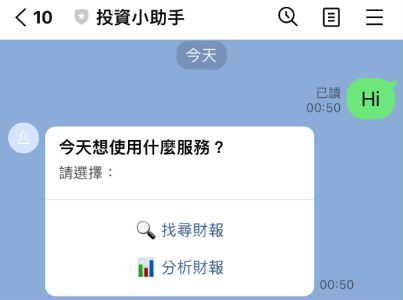

-財務找尋畫面

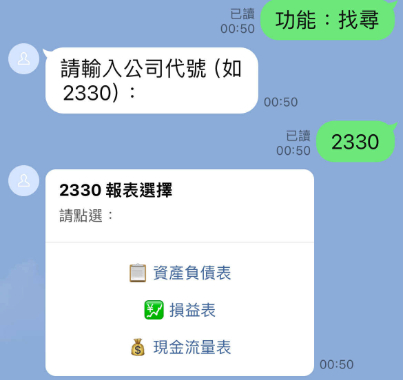

-財報分析畫面
*此處因為畫面內容較大，因此改採用電腦版的 line 顯示

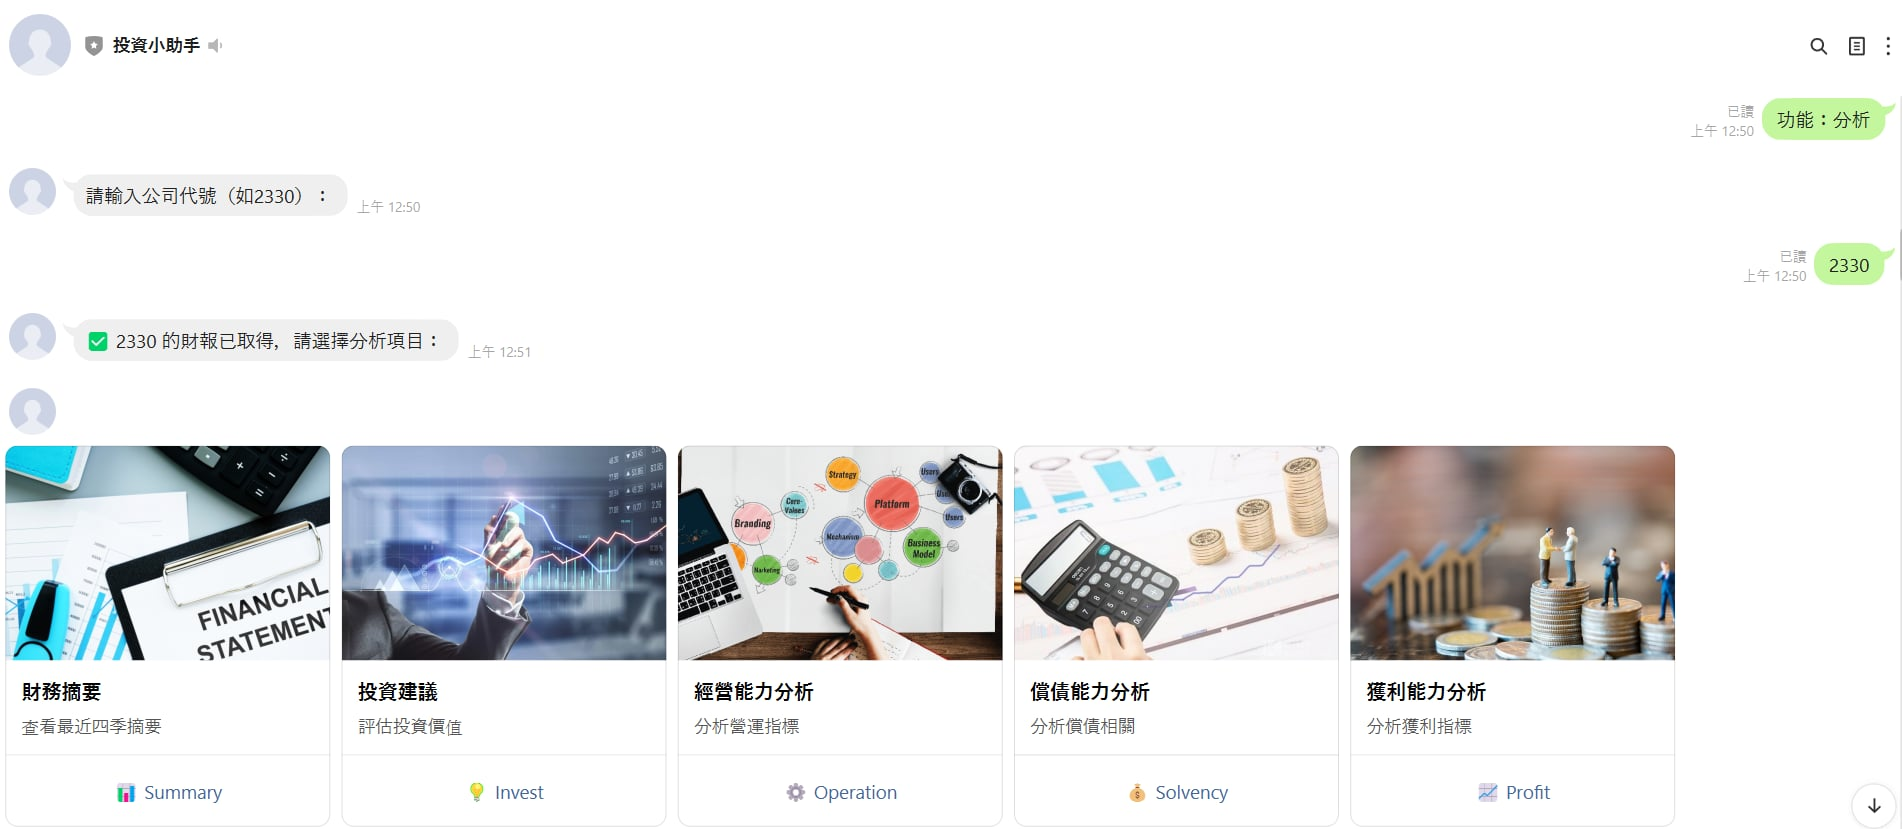

-財報分析 Gemini 回覆內容

1.財務摘要

  >這家公司財務狀況概況：  
  >💰獲利能力：
  *   營收和毛利穩定，但2025Q1營收較低
  *   營業利益率和稅後淨利率維持在較高水平📈
  *   股東權益報酬率和資產報酬率表現不錯，但需要注意是否能維持

  >💪經營能力：
  *   應收帳款和存貨管理大致穩定，但應收帳款收現日數稍長
  *   固定資產和總資產週轉率相對穩定
  *   應付帳款付現日數偏高

  >⚖️償債能力：
  *   現金比率、速動比率和流動比率都高於150%，短期償債能力強💪
  *   負債對淨值比率約55%，財務結構尚可接受
  *   利息保障倍數高，利息支付壓力小

  >整體來看，公司獲利能力佳，短期償債能力強，但經營能力還有提升空間。需要關注應收帳款管理和提升資產使用效率。🧐

2.投資建議

  >公司財務分析與投資建議 📊

  >根據提供的財務報表，我將從長期和短期投資角度分析，並給出具體建議。

  >📈 公司概況：  
  *   整體：資產、營收、淨利持續成長📈，財報評分高（91分），顯示公司經營狀況良好。  
  *   獲利能力：毛利率、營業利益率、稅後淨利率皆維持高水準。股東權益報酬率和資產報酬率預估皆在25%以上，營運效率佳。
  *   財務結構：負債比率穩定，股東權益佔比高。
  *   現金流：營業活動現金流量穩定，能支撐營運。

  >長期投資建議 ⏳
  *   投資價值：公司基本面強勁💪，獲利能力佳，具備長期投資價值。
  *   成長性：營收、淨利持續成長，顯示公司具備良好的成長潛力🌱。
  *   風險：注意應收帳款和存貨的佔營收比率，避免過高。
  *   投資工具：
    *   股票：在台灣證券交易所購買股票。
    *   ETF：若有追蹤類似產業的ETF，可考慮配置。
    *   定期定額：分散風險，長期持有。

  >短期投資建議 ⏱️
  *   操作策略：可關注短期營收成長動能，搭配技術分析尋找買賣點。
  *   風險：短期股價波動風險較高，需謹慎操作。
  *   投資工具：
    *   權證：如認購權證，放大槓桿，但風險較高。
    *   期貨：如股票期貨，可多空操作，但需注意保證金風險。

  >⚠️ 注意事項：
  *   本建議僅供參考，投資前請務必自行研究判斷。
  *   隨時關注公司公告、新聞，以及整體市場變化。

  >希望這些資訊能幫助你做出更明智的投資決策！👍

3.經營能力分析

  >這家公司經營能力分析：

  >👍表現良好：
  *   獲利能力佳：營業毛利率、營業利益率、稅前淨利率、稅後淨利率高且穩定，近一年來獲利呈現成長趨勢📈。
  *   現金流量充裕：營業活動淨現金流入穩定，現金比率高，顯示短期償債能力強💪。
  *   資產品質優良：流動資產佔比高，資產年成長率高，顯示公司擴張速度快🚀。
  *   股東權益報酬率高：股東權益報酬率(年預估)穩定，顯示公司為股東創造價值的能力強🥇。
  *   總資產週轉率穩定：總資產週轉率穩定成長，表示公司資產利用效率逐漸提升。

  >⚠️需要注意：
  *   應收帳款週轉天數略長：應收帳款收現日數略長，需關注應收帳款回收狀況，避免壞帳風險🧾。
  *   營業費用佔比略高：營業費用率略高，需持續關注費用控制，提升獲利空間💰。
  *   負債比率略高：負債對淨值比率偏高，需注意財務槓桿風險⚠️。
  *   每股自由現金流量不穩定：顯示公司再投資的能力不穩定。

  >🔮未來展望：
  *   若能有效控制營業費用、縮短應收帳款回收期，有望進一步提升獲利能力🚀。
  *   持續關注負債比率，維持穩健的財務結構⚖️。
  *   現金流量比高，公司現金足以支應短期負債。
  *   可關注其股利政策，若公司有足夠的現金，且具備回饋股東的意願，股價或許還有上漲空間。

4.償債能力分析

  >綜合分析，這家公司在償債能力方面呈現以下情況：

  >短期償債能力：👍
  *   現金比率、速動比率和流動比率均遠高於100%，顯示短期償債能力非常強勁。
  *   現金比率穩定，速動比率和流動比率有小幅上升趨勢，流動資產增長速度大於流動負債。

  >長期償債能力：⚠️
  *   負債對淨值比率逐季下降，負債佔股東權益比例正在降低。
  *   長期資金適合率高於100%，表示長期資金足以支應固定資產，但比率在下降。
  *   應付公司債佔總資產比例偏高，需關注其還款計畫。

  >表現與未來展望：📈
  *   整體而言，公司償債能力良好。
  *   獲利能力穩定，營業收入、毛利和淨利持續增長，有助於未來償債。
  *   現金流量穩定，營業活動現金流量為正，可提供償債資金。
  *   股東權益持續增加，強化了公司的財務基礎。

  >建議關注事項：🧐
  *   持續關注應付公司債的還款計畫，確保能如期償還。
  *   密切注意長期資金適合率的變化，維持長期資金的穩定性。
  *   注意利息保障倍數，雖然目前數值很高，但若利潤下滑可能影響償債能力。

  >表情符號總結：👍📈⚠️🧐

5.獲利能力分析

  >整體獲利能力分析：  
  📈 公司獲利能力表現良好，多項指標顯示穩定成長。  
  💰 營收、毛利、營業利益、稅前淨利、稅後淨利皆呈現年成長。  
  📊 獲利能力指標如毛利率、營業利益率、淨利率等，維持在不錯的水準。  
  🚀 股東權益報酬率和資產報酬率也呈現穩定狀態。

  >需要注意的地方：  
  🤔 應收帳款週轉率略有下降，收現日數增加，需關注收款效率。  
  🏢 營業費用率略有上升，需留意費用控制。  
  📊 負債比率偏高，需關注財務結構的穩健性。  
  💹 現金流量比率波動較大，需關注現金流量的穩定性。

  >未來可能的表現：  
  🌟 若能有效控制費用、提高收款效率，獲利能力有望進一步提升。  
  🚀 資產持續擴張，股東權益持續增加。  
  🌱 整體財務狀況良好，具備長期發展的潛力。  
  👍財報評分維持高分。


使用者可於 LINE 上輸入欲查詢之企業代號，即能取得 Goodinfo 上提供的企業三大財務報表（資產負債表、損益表與現金流量表）；同時，也可使用 Gemini 生成式語言模型進行財務分析，包括財務摘要、投資建議、以及對經營能力、償債能力與獲利能力的分析及建議。
- 使用者於 LINE 傳送訊息，即會跳出主選單-財報找尋或財報分析
- 使用者於主選單選擇欲使用的服務後， LINE 傳送訊息請使用者輸入代號
- 使用者輸入代號後即跳出所點選服務的選單，例如:

  1.   財報找尋
    *   資產負債表
    *   損益表
    *   現金流量表
  2.   財報分析
    *   財務摘要
    *   投資建議
    *   經營能力分析
    *   償債能力分析
    *   獲利能力分析
- 使用者於選單選擇服務後，將可得到財報網址或是 Gemini 的分析回覆

### 效益分析

- 使用者測試報告

| 測試項目 | 測試結果 | 備註 |
|----------|----------|------|
| 功能完整性 | 80% 滿意 | 能回覆財報分析重點，但仍需更多方面的分析 |
| 界面設計 | 90% 滿意 | LINE 是大部分的人都熟悉的軟體，且搭配表單互動，使用上更為便利和清楚 |
| 性能表現 | 回應時間較長 | 尚可接受，因爬取資料需要時間 |
| 使用者滿意度 | 平均 4.3/5 | 可降低閱讀財報的門檻 |
| 建議回饋 | 文字較多 | 可以以圖像化的方式呈現財務數據 |

- 系統是否達到目標？  
是。Line Bot 成功讓使用者透過 LINE 與生成式 AI 互動，並獲取想要的資訊，提供給使用者投資時的公司財務分析建議，符合預期成果。

## 未來發展與改進

### 需改進地方  
- 重新執行程式網址需重新設定
    
  當重新執行程式時得到的網址會改變，因此需重新於 LINE Bot Webhook 上重新綁定網址。

  → 曾嘗試使用 Vercel 來建立固定網址，但由於整體檔案大小超過 Vercel 的 250MB 限制，因此仍需尋找其他免費且無此限制的部署平台，以解決此問題。
  
- 增加可選擇功能

  除了基本的財務狀況外，公司治理、ESG的表現或公司經營投資策略等都會影響到一間企業的評價，因此需要更完善的功能分析。

### 未來規劃  
- 整合圖像生成功能（如 Gemini 支援圖片輸出），提升報表閱讀的效率與吸收度  
- 擴充查詢內容與資料來源


## 圖片來源

https://kscthinktank.com.tw/wp-content/uploads/2023/11/22-1024x576.png  
https://bank.sinopac.com/sinopacBT/webevents/FinancialManagement/userfiles/article/058pic2.jpg  
https://expup.com/tw/wp-content/uploads/2019/11/Platformphoto-01-1.png  
https://att.kuaiji.com/edit/image/202008/1597219698908474.jpg  
https://ism.bwnet.com.tw/image/pool/sm/2019/01/1355c282483d9a4bb0a6bef9eac0030a.jpg